In [1]:
from model_builder import ModelBuilder
from model_builder_keras import ModelBuilder as KerasModelBuilder

from preprocessing import Preprocessor
from plotting_other import Plotter
from plotting import plot_dataset
#from shapley import ProcessAttributor
from shapley_improved import ProcessAttributorSHAP
from shapley_improved_other import ProcessAttributorSHAPMLP

from universal_filtering import CustomSpearmanFilter
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
#from sklearn.linear_model import Ridge
#from sklearn.linear_model import Lasso
from sklearn.base import BaseEstimator, RegressorMixin
import numpy as np

# Basic Deep Learning with Sklearn MLP
from sklearn.neural_network import MLPRegressor
from sklearn.inspection import permutation_importance

# Deep Learning with Keras Tensorflow
#import keras
from keras import layers, optimizers, callbacks, Sequential
#https://ipython.org/ipython-doc/3/config/extensions/autoreload.html
%load_ext autoreload
%autoreload 2

I0000 00:00:1784819922.165385 1397291 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784819922.207243 1397291 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784819923.476590 1397291 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
train_sarek = [
    pd.read_parquet("../../../../ProcessEnergyAccounting/runs/nfcore-20260701T215234Z/datasets/sarek_1_0207.parquet"),
    pd.read_parquet("../../../../ProcessEnergyAccounting/runs/nfcore-20260702T193504Z/datasets/sarek_2_0207.parquet")
]
test_sarek = pd.read_parquet("../../../../ProcessEnergyAccounting/runs/nfcore-20260708T212252Z/datasets/sarek3_0907.parquet")


In [3]:
training_data = pd.concat(train_sarek, ignore_index=True)
training_data = training_data
test_data = test_sarek
PNG_NAME = "mlp_pred_sarek"

features = [
    "delta_cpu_ns",
    "delta_io_bytes",
    "delta_net_send_bytes",
    "context_switches",
    "syscall_count",
    "delta_rss_memory",
    "delta_cpu_time_psutil",
    "delta_cpu_time_proc",
    "syscall_class_file",
    "syscall_class_network",
    "syscall_class_memory",
    "syscall_class_process",
    "syscall_class_other",
    "syscall_class_sched",
    "syscall_class_signal",
    "syscall_class_time",
    "delta_cycles",
    "delta_cache_misses",
    "delta_instructions",
    "delta_branch_instructions",
]


In [4]:
preprocessor_train = Preprocessor(training_data, features)
X_train_FULL, y_train, t_train, _ = preprocessor_train.preprocess_no_split()

Dropped 0 timestamps.


In [5]:
#plot_dataset(t_train, y_train, "multi_training")


In [6]:
#build_model = ExplainableBoostingRegressor( interactions=2, max_rounds=2000, n_jobs=-1, random_state=42)
model = RandomForestRegressor(n_estimators=100,  n_jobs=-1, random_state=42)
#build_model = MLPRegressor(activation="relu", solver="adam", random_state=42)



In [7]:
#These thresholds could be fine tuned
automatic_feature_selection = Pipeline(steps=[
    ('variance', VarianceThreshold(threshold=0.01)), #explain this

    ('decorrelate', CustomSpearmanFilter(threshold=0.80)),
    ('scaler', StandardScaler()),
    ('select_features', SelectFromModel(model, threshold='0.5*median'))
])

automatic_feature_selection.set_output(transform="pandas")
automatic_feature_selection.fit_transform(X_train_FULL, y_train)
good_features = automatic_feature_selection.get_feature_names_out().tolist()
X_train = X_train_FULL[good_features]
print("Selected columns:")
print(good_features)


#plot_dataset(t_train, y_train, "multi_training")

Selected columns:
['delta_cpu_ns', 'delta_io_bytes', 'delta_net_send_bytes', 'context_switches', 'syscall_count', 'delta_rss_memory', 'delta_cpu_time_proc', 'syscall_class_file', 'syscall_class_network', 'syscall_class_memory', 'syscall_class_process', 'syscall_class_other']


In [8]:
preprocessor_test = Preprocessor(test_data, good_features)
X_test, y_test, t_test , X_test_unaggregated = preprocessor_test.preprocess_no_split()

#plot_dataset(t_test, y_test, "multi_testing")

Dropped 0 timestamps.


In [9]:
plot_dataset(t_test, y_test, "multi_testing")

### Sklearn MLP

In [10]:
build_model_mlp = MLPRegressor(hidden_layer_sizes=(128,32,16),
                    activation='relu',
                    solver='adam',
                    learning_rate_init=0.0001,
                    max_iter=500,
                    #alpha = 0.0000675,
                    batch_size=64,
                    early_stopping=True,    # Crucial for time-series stability
                    #validation_fraction=0.1,
                    random_state=42)

In [11]:
builder = ModelBuilder(X_train, X_test, y_train, y_test, build_model_mlp, StandardScaler())
y_pred, learned_idle_power = builder.run_and_save_model()


  R² Score:  0.9064
  MAE:       6.05 Ws (3.01% of mean)
----------------------------------
The model's learned baseline idle interval energy is: 143.88 Ws
----------------------------------
/n


In [12]:
plotter = Plotter(y_pred,y_test, t_test,"mlp")#, window_start =50, window_end=200)
plotter.plot_and_save("", PNG_NAME)

In [13]:
#check if we ann pass this differently
#attributor = ProcessAttributorSHAPMLP( builder.X_test_scaled, builder.model, builder.scaler)
#attributor.attribute(X_test_unaggregated,good_features,t_test.values, "mlp_graphs_")

### Deep Learning with Keras

Build the 1D-CNN in Keras (Tutorials)

- https://keras.io/guides/sequential_model/
- https://keras.io/examples/timeseries/timeseries_classification_from_scratch/
- https://www.tensorflow.org/tutorials/structured_data/time_series#recurrent_neural_network
- https://keras.io/examples/timeseries/timeseries_classification_from_scratch/



In [14]:
num_features = len(good_features)

In [15]:
# Models used
# Convolutional Neural Network (1D)
cnn_model = Sequential([

    layers.Input(shape=(num_features, 1)), # (num_features, sequence_length) #Only current value
    layers.Conv1D(32, kernel_size=num_features, padding='same', activation="relu"),
    layers.BatchNormalization(),

    layers.Conv1D(32, kernel_size=num_features, padding='same', activation="relu"),
    layers.BatchNormalization(),

    #layers.Conv1D(32, kernel_size=num_features, padding='same', activation="relu"),
    #layers.BatchNormalization(),
    
    layers.Flatten(),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
    
])

# Feed Forward Neural Network
ffnn_model = Sequential([
    layers.Input(shape=(num_features, 1)), # (num_features, sequence_length) #Only current value
    layers.Flatten(),
    #layers.GlobalAveragePooling1D(),
    #layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    #layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1)
    
])

# LSTM Model
lstm_model = Sequential([
    layers.Input(shape=(num_features, 1)), # (num_features, sequence_length) #Only current value
    layers.BatchNormalization(),
    layers.LSTM(64, return_sequences=True),
    layers.LSTM(64, return_sequences=True),
    layers.Flatten(),
    #layers.GlobalAveragePooling1D(),
    #layers.Dropout(0.2),
    #layers.Dense(32, activation='relu'),
    layers.Dense(1)
    
])

In [16]:
builder_lstm = KerasModelBuilder(X_train, X_test, y_train, y_test, lstm_model, StandardScaler())
y_pred_lstm, learned_idle_power = builder_lstm.run_and_save_model()

Epoch 1/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 17202.5859 - mae: 117.2892 - val_loss: 784.5626 - val_mae: 26.6311
Epoch 2/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 1096.3872 - mae: 23.0232 - val_loss: 182.8696 - val_mae: 12.3642
Epoch 3/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 428.7793 - mae: 14.9628 - val_loss: 139.9506 - val_mae: 9.6633
Epoch 4/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 298.8172 - mae: 11.6470 - val_loss: 101.4467 - val_mae: 7.1296
Epoch 5/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 252.1812 - mae: 9.9048 - val_loss: 89.5037 - val_mae: 6.6636
Epoch 6/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 239.1424 - mae: 9.3655 - val_loss: 84.9817 - val_mae: 6.1861
Epoch 7/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 235.3928 - mae: 9.2122 - val_loss: 86.0674 - val_mae: 6.2931
Epoch 8/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 234.0834 - mae: 9.1755 - val_loss: 84.4339 - val_mae: 6.1465
Epoch 9/30

In [17]:
#plotter = Plotter(y_pred=y_pred_lstm,y_test=y_test, t_test= t_test,alg_name="lstm",window_start=150, window_end=200)
plotter = Plotter(y_pred=y_pred_lstm,y_test=y_test, t_test= t_test,alg_name="lstm")
#plotter.plot_only("lstm_")
plotter.plot_and_save("ltsm_")

In [19]:
builder_cnn = KerasModelBuilder(X_train, X_test, y_train, y_test, cnn_model, StandardScaler())
y_pred_cnn, learned_idle_power = builder_cnn.run_and_save_model()

Epoch 1/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 12334.5801 - mae: 77.9011 - val_loss: 7070.1948 - val_mae: 83.7940
Epoch 2/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 159.2585 - mae: 8.9427 - val_loss: 735.3738 - val_mae: 26.3891
Epoch 3/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 113.4938 - mae: 7.5750 - val_loss: 96.4775 - val_mae: 8.1667
Epoch 4/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 97.6964 - mae: 6.8714 - val_loss: 53.1083 - val_mae: 5.3595
Epoch 5/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 94.9871 - mae: 6.8495 - val_loss: 37.9893 - val_mae: 4.1623
Epoch 6/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 88.7427 - mae: 6.4797 - val_loss: 30.6741 - val_mae: 3.2976
Epoch 7/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 84.5785 - mae: 6.3385 - val_loss: 32.2066 - val_mae: 3.4482
Epoch 8/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 80.3347 - mae: 6.1272 - val_loss: 42.7464 - val_mae: 4.5936
Epoch 9/30
209/209 ━━━━━━━━━━

In [21]:
plotter = Plotter(y_pred=y_pred_cnn,y_test=y_test, t_test= t_test,alg_name="cnn_1d")
#plotter.plot_only("cnn_1d")
plotter.plot_and_save("cnn_1d_")

In [24]:
#64-16 # Faster other models
builder_ffnn = KerasModelBuilder(X_train, X_test, y_train, y_test, ffnn_model, StandardScaler())
y_pred_ffnn, learned_idle_power = builder_cnn.run_and_save_model()

Epoch 1/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 67.6539 - mae: 5.5482 - val_loss: 26.7605 - val_mae: 2.8945
Epoch 2/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 66.7818 - mae: 5.5294 - val_loss: 25.7852 - val_mae: 2.8989
Epoch 3/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 64.5031 - mae: 5.3955 - val_loss: 30.0622 - val_mae: 3.5595
Epoch 4/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 64.6488 - mae: 5.4655 - val_loss: 25.3949 - val_mae: 2.8689
Epoch 5/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 65.5294 - mae: 5.5181 - val_loss: 39.1776 - val_mae: 4.1732
Epoch 6/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 65.0084 - mae: 5.4512 - val_loss: 29.4778 - val_mae: 3.3407
Epoch 7/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 64.5860 - mae: 5.4278 - val_loss: 45.0707 - val_mae: 5.4875
Epoch 8/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 65.5176 - mae: 5.4995 - val_loss: 26.3315 - val_mae: 3.0587
Epoch 9/30
209/209 ━━━━━━━━━━━━━━━━━━━━ 

In [25]:
builder_ffnn

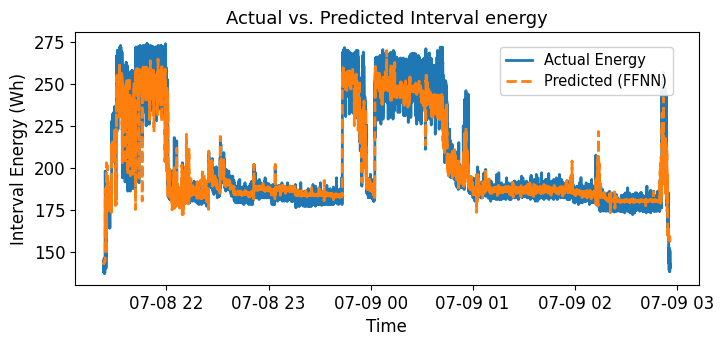

In [26]:
plotter = Plotter(y_pred=y_pred_ffnn,y_test=y_test, t_test= t_test,alg_name="ffnn")
plotter.plot_only("ffnn_")
plotter.plot_and_save("ffnn_")